# Data Science Project: Big Mart Sales Analysis

In [34]:
# Load in the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Load in our dataset from Kaggle in a .csv format

In [35]:
# Read in the data from our csv file containing item and outlet sales information
df_groceries = pd.read_csv('../data/big_mart_sales.csv', delimiter=',', header='infer')

# Report information regarding the dataset

df_groceries.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [36]:
# Show the first 5 rows of the dataset
df_groceries.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## 1. Handling empty data entries

In [37]:
# Let's identify the columns that contain missing values or entries containing Nan or None
missing_values = df_groceries.isnull().sum()
print(missing_values)

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


### Missing data

Item weight and outlet size are missing for some rows. To take care of item weight lets use the median for item's of the same type as a placeholder. For outlet size let's use the mode for outlets with the same type since the data is stored as strings.

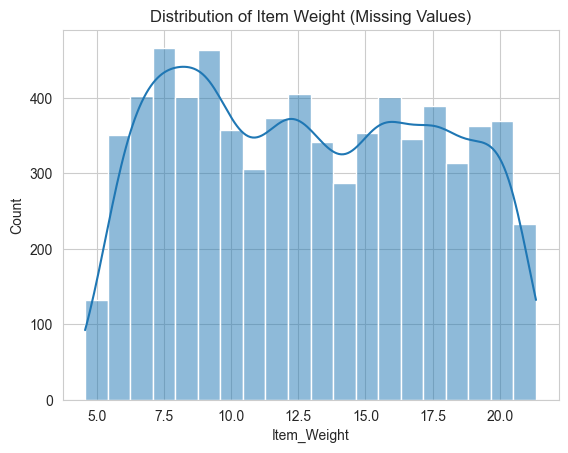

In [38]:
# Visualise the Item Weight data with Seaborn and Matplotlib while data is missing
sns.histplot(df_groceries["Item_Weight"], kde=True)
plt.title("Distribution of Item Weight (Missing Values)")
plt.show()


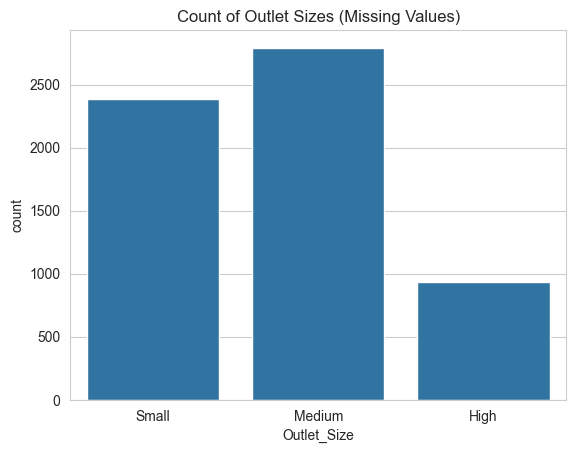

In [39]:
# Visualise the missing Outlet Size data with Seaborn and Matplotlib

sns.countplot(data=df_groceries, x="Outlet_Size", order=["Small", "Medium", "High"])
plt.title("Count of Outlet Sizes (Missing Values)")
plt.show()

In [40]:
# Item Weight
df_groceries['Item_Weight_filled'] = df_groceries['Item_Weight'].fillna(df_groceries.groupby("Item_Type")["Item_Weight"].transform("median"))

In [41]:
# Outlet Size
# Fill missing outlet sizes with the mode of the outlet size for matching outlet types
# Use a lamda function to check if the mode is empty before trying to access the first element, to avoid errors in case of empty groups
df_groceries["Outlet_Size_filled"] = df_groceries["Outlet_Size"].fillna(
    df_groceries.groupby("Outlet_Type")["Outlet_Size"]
      .transform(lambda x: x.mode()[0] if not x.mode().empty else x)
)

In [42]:
# Create outlet-level DataFrame (one row per outlet, 10 unique outlets)
df_outlets = df_groceries.drop_duplicates(subset='Outlet_Identifier').reset_index(drop=True)

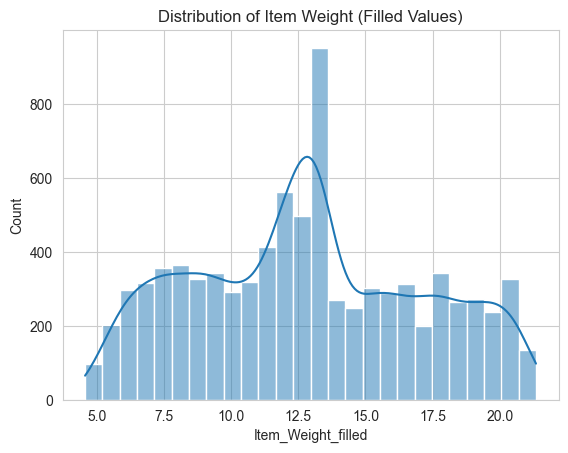

In [43]:
# Visualise the Item Weight data with Seaborn and Matplotlib after filling data
sns.histplot(df_groceries["Item_Weight_filled"], kde=True)
plt.title("Distribution of Item Weight (Filled Values)")
plt.show()

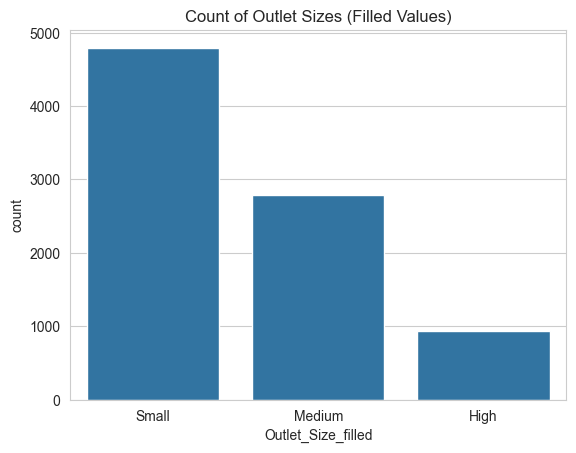

In [44]:
# Visualise the missing Outlet Size data with Seaborn and Matplotlib

sns.countplot(data=df_groceries, x="Outlet_Size_filled", order=["Small", "Medium", "High"])
plt.title("Count of Outlet Sizes (Filled Values)")
plt.show()

### Thoughts on empty data and methods to insert replacement values

The addition of data points equal to the median of items with the same type succeeded in maintaining a normal distribution, but did introduce an artificial peak around 13. This may become relevant if item weight data is used to inform models on sales data in the future. It may be more effective, in that case, to map item weight values to reflect the distribution of the present data.

Classifications of small outlet_sizes were introduced after filling in the empty data entries. This now makes small the most common outlet size. Similarly to item weight, this artificial increase needs to be considered if using outlet_size as a factor in future predictions of sales and revenue.

## 2. Exploratory Data Analysis

Our analysis is primarily concerned with the following categories:

1. Item Sales (`Item_Outlet_Sales`)
2. Item Revenue (`Item_MRP` * `Item_Outlet_Sales`)
3. Outlet Information (as it relates to sales performance)
    - Size (`Outlet_Size`)
    - Age (Current Year - `Outlet_Establishment_Year`)
    - Location (`Outlet_Location_Type`)
    - Type (`Outlet_Type`)

Therefore, we want to visualise data relevant to our variables of interest.

### Seaborn Analysis

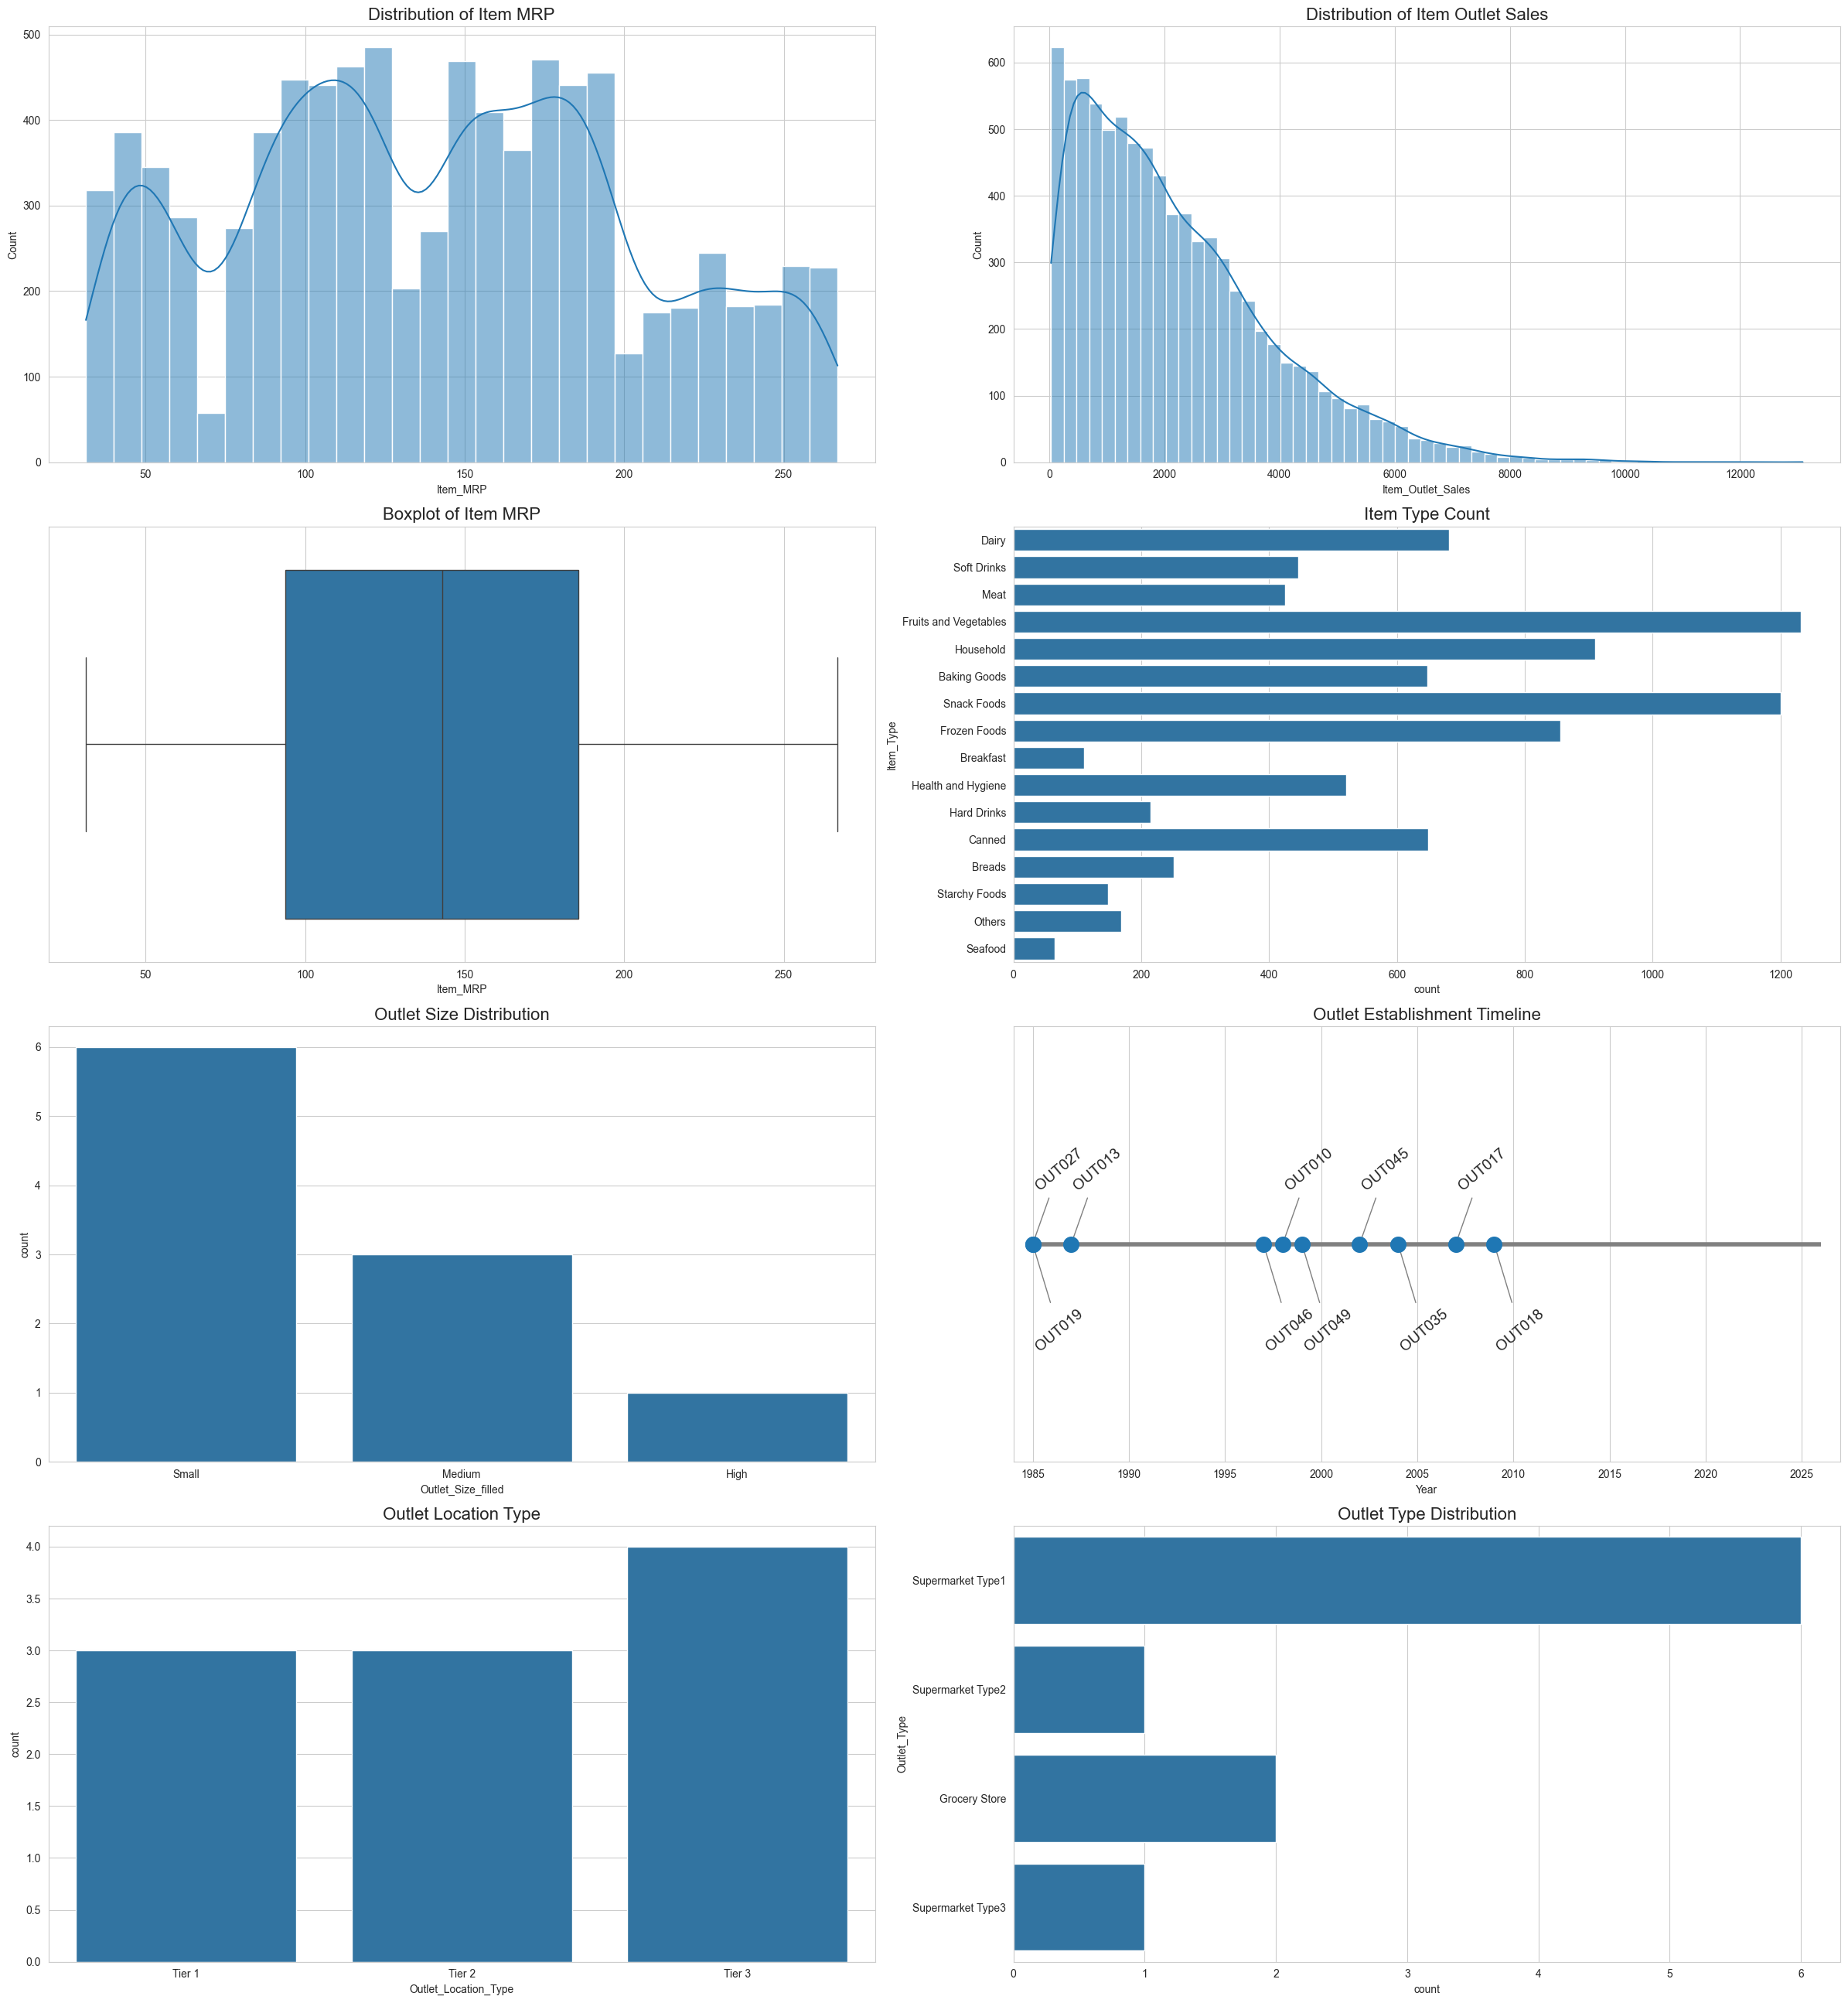

In [63]:
sns.set_style("whitegrid")

# Create a 4x2 grid of subplots for visualizations
fig, axes = plt.subplots(4, 2, figsize=(24, 26))
axes = axes.flatten()

## Visualise the distribution of Item MRP and Item Outlet Sales, and the boxplot of Item MRP, and the count of Item Type

# 1 Distribution of Item_MRP
sns.histplot(df_groceries['Item_MRP'], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Item MRP", fontsize=16)

# 2 Distribution of Sales
sns.histplot(df_groceries['Item_Outlet_Sales'], kde=True, ax=axes[1])
axes[1].set_title("Distribution of Item Outlet Sales", fontsize=16)

# 3 Boxplot MRP
sns.boxplot(x=df_groceries['Item_MRP'], ax=axes[2])
axes[2].set_title("Boxplot of Item MRP", fontsize=16)

# 4 Item Type count
sns.countplot(y='Item_Type', data=df_groceries, ax=axes[3])
axes[3].set_title("Item Type Count", fontsize=16)

## Outlet distribution plots — based on 10 unique outlets (deduplicated by Outlet_Identifier)

# 5 Outlet Size distribution
sns.countplot(x='Outlet_Size_filled', data=df_outlets, order=['Small', 'Medium', 'High'], ax=axes[4])
axes[4].set_title("Outlet Size Distribution", fontsize=16)

# 6 Outlet Establishment Year — timeline from first outlet to 2026
years = df_outlets['Outlet_Establishment_Year'].values
outlets = df_outlets['Outlet_Identifier'].values
sorted_idx = years.argsort()
years, outlets = years[sorted_idx], outlets[sorted_idx]

axes[5].hlines(0, years.min(), 2026, colors='gray', linewidth=4)
axes[5].scatter(years, [0]*len(years), s=200, zorder=5)
for i, (year, outlet) in enumerate(zip(years, outlets)):
    offset = 50 if i % 2 == 0 else -100
    axes[5].annotate(outlet, xy=(year, 0), xytext=(0, offset),
                     textcoords="offset points",
                     rotation=40, ha='left', fontsize=14,
                     arrowprops=dict(arrowstyle='-', color='gray', lw=1))
axes[5].set_xlim(years.min() - 1, 2027)
axes[5].set_yticks([])
axes[5].set_title("Outlet Establishment Timeline", fontsize=16)
axes[5].set_xlabel("Year")

# 7 Outlet Location Type distribution
sns.countplot(x='Outlet_Location_Type', data=df_outlets, order=['Tier 1', 'Tier 2', 'Tier 3'], ax=axes[6])
axes[6].set_title("Outlet Location Type", fontsize=16)

# 8 Outlet Type distribution
sns.countplot(y='Outlet_Type', data=df_outlets, ax=axes[7])
axes[7].set_title("Outlet Type Distribution", fontsize=16)

plt.tight_layout()
plt.show()


### We may also benefit from visualisations of relationships between different parameters

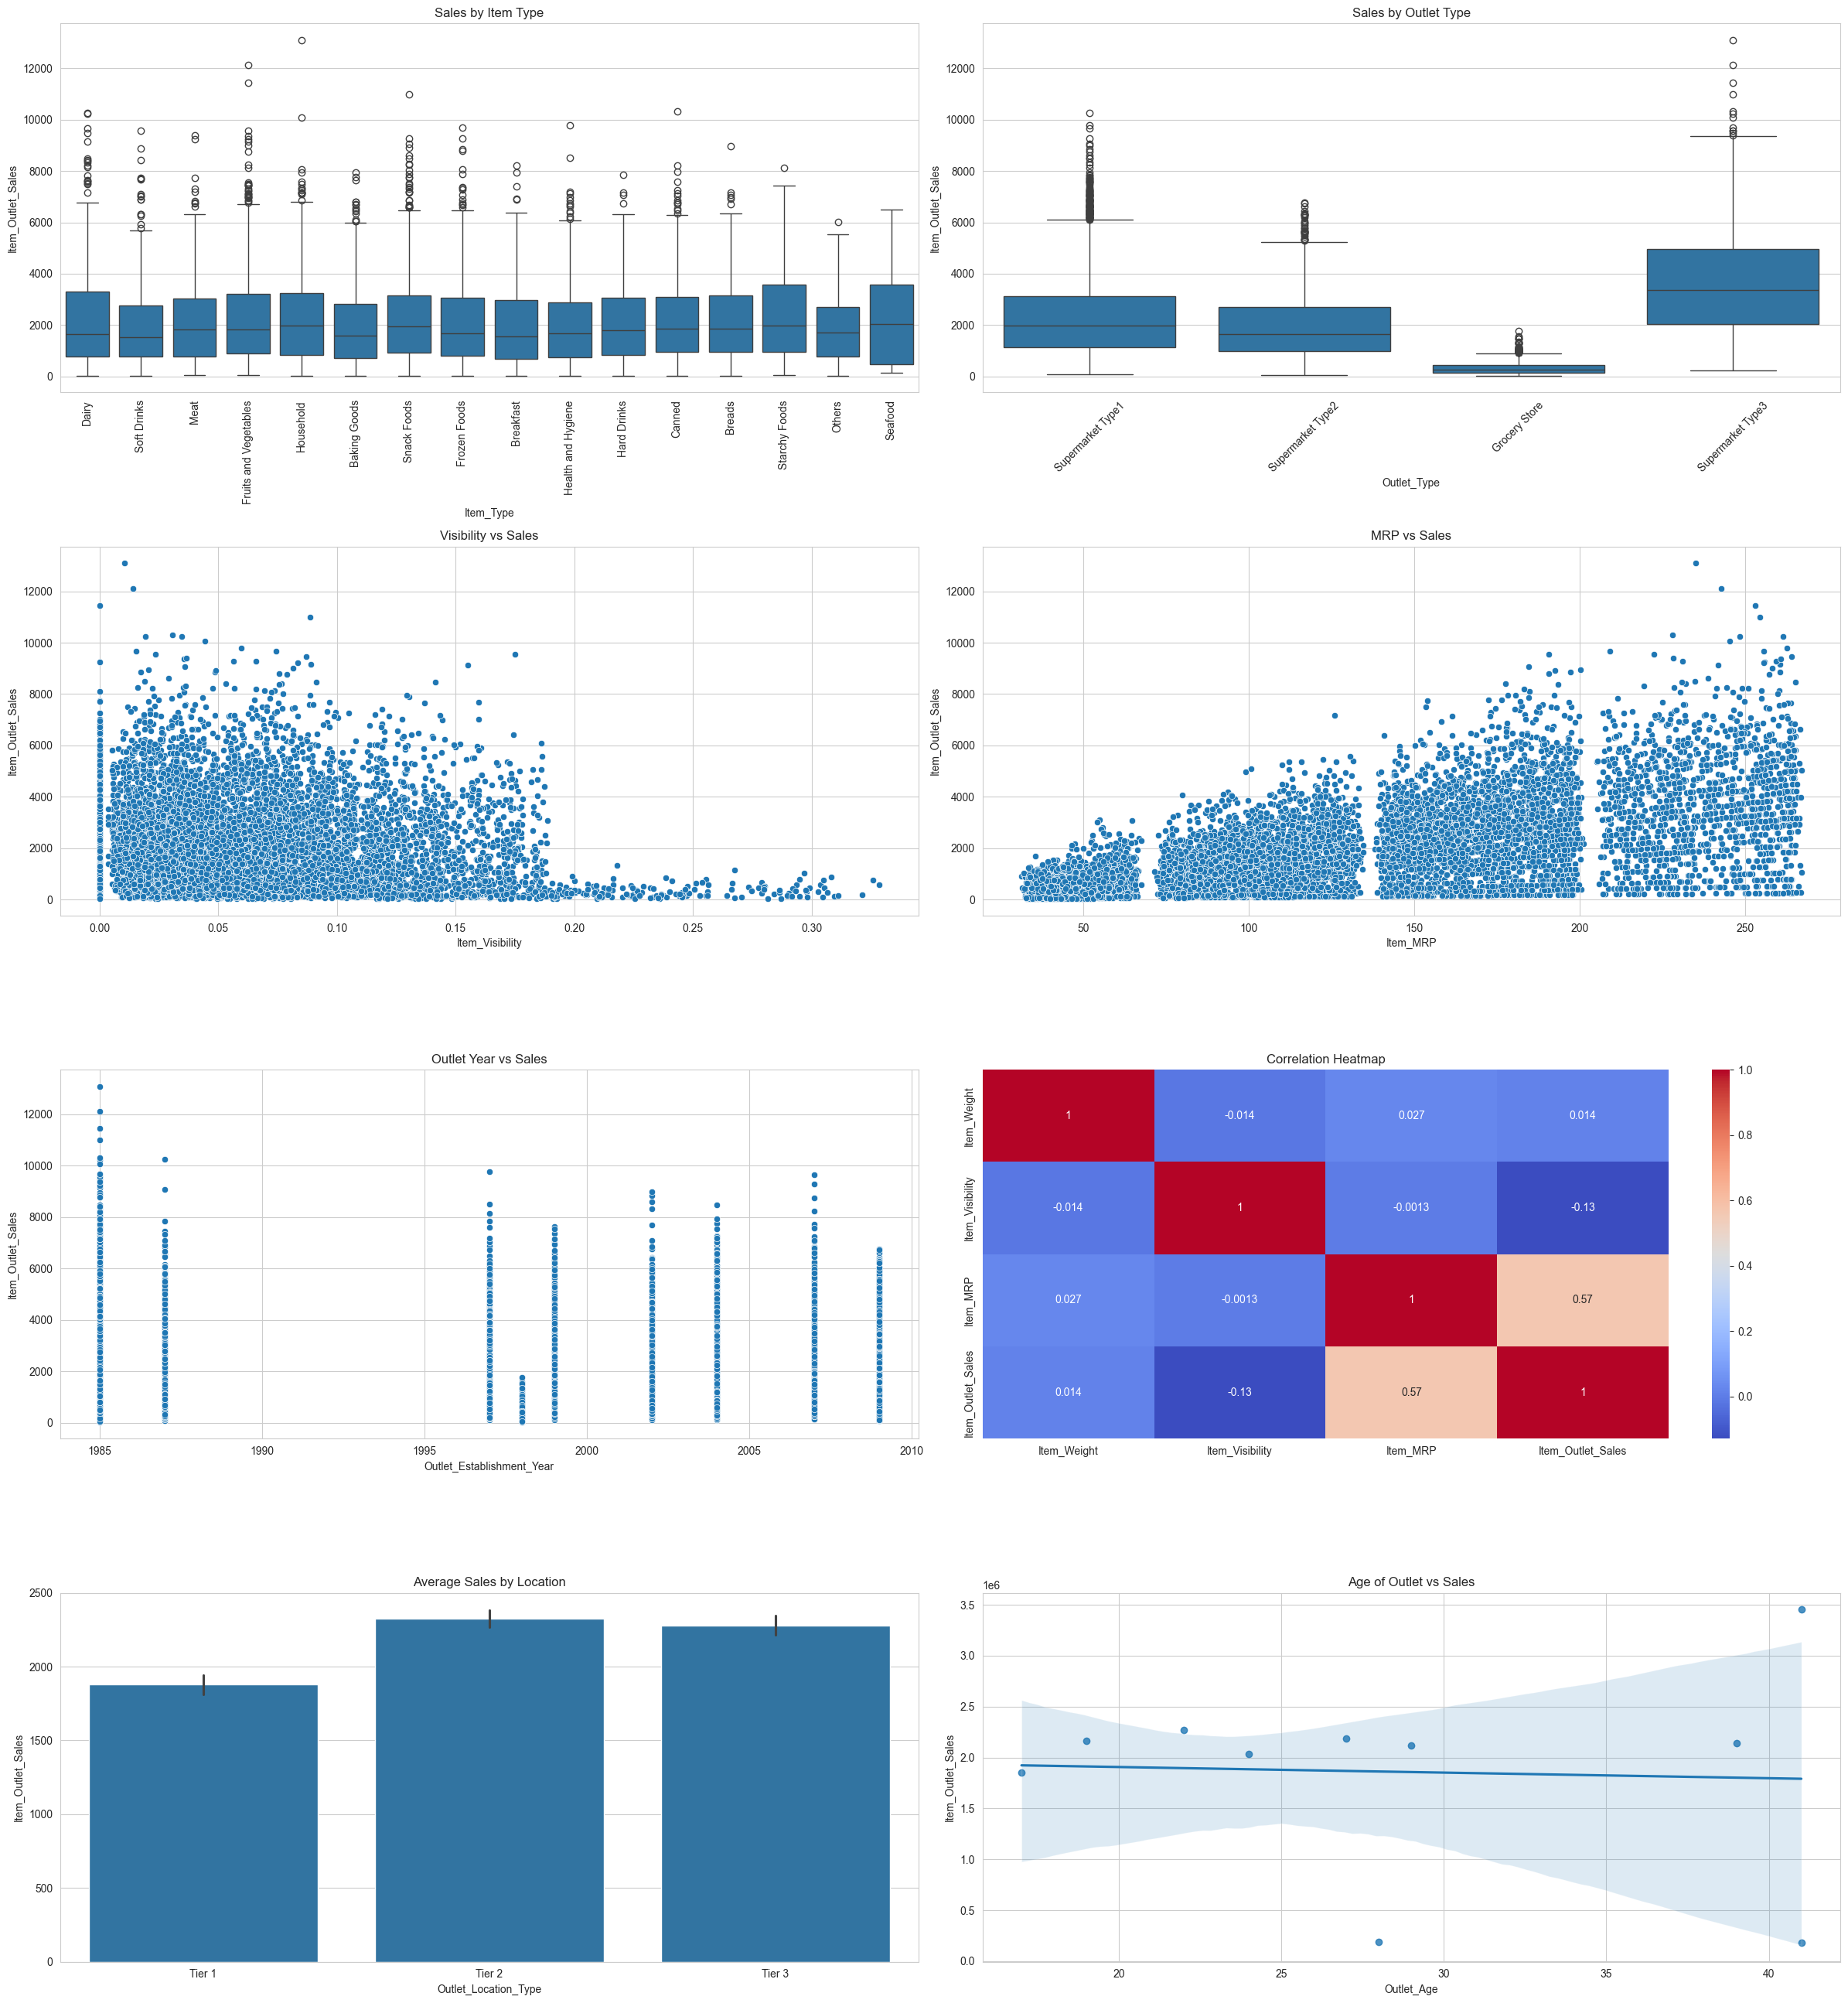

In [46]:
sns.set_style("whitegrid")

# Create a 4x2 grid of subplots for visualizations
fig, axes = plt.subplots(4, 2, figsize=(24, 26))
axes = axes.flatten()

# 9 Item Type vs Sales
sns.boxplot(x='Item_Type', y='Item_Outlet_Sales', data=df_groceries, ax=axes[0])
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_title("Sales by Item Type")

# 10 Outlet Type vs Sales
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df_groceries, ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title("Sales by Outlet Type")

# 11 Visibility vs Sales
sns.scatterplot(x='Item_Visibility', y='Item_Outlet_Sales', data=df_groceries, ax=axes[2])
axes[2].set_title("Visibility vs Sales")

# 12 MRP vs Sales
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df_groceries, ax=axes[3])
axes[3].set_title("MRP vs Sales")

# 13 Establishment Year vs Sales
sns.scatterplot(x='Outlet_Establishment_Year', y='Item_Outlet_Sales', data=df_groceries, ax=axes[4])
axes[4].set_title("Outlet Year vs Sales")

# 14 Correlation Heatmap
corr = df_groceries[['Item_Weight','Item_Visibility','Item_MRP','Item_Outlet_Sales']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[5])
axes[5].set_title("Correlation Heatmap")

# 15 Average Sales by Outlet Location
sns.barplot(x='Outlet_Location_Type', y='Item_Outlet_Sales', data=df_groceries, order=['Tier 1', 'Tier 2', 'Tier 3'], ax=axes[6])
axes[6].set_title("Average Sales by Location")

# 16 Age of Outlet vs Sales
df_groceries['Outlet_Age'] = 2026 - df_groceries['Outlet_Establishment_Year']
outlet_sales_by_age = df_groceries.groupby(['Outlet_Identifier','Outlet_Age'], as_index=False)['Item_Outlet_Sales'].sum()
sns.regplot(x='Outlet_Age', y='Item_Outlet_Sales', data=outlet_sales_by_age, ax=axes[7])
axes[7].set_title("Age of Outlet vs Sales")

plt.tight_layout()
plt.show()

## 3. Feature: What are the top performing item types?

In [47]:
# First let's create a new column for the revenue per item by multiplying Item MRP by Item Sales
df_groceries['Revenue_per_Item'] = df_groceries['Item_MRP'] * df_groceries['Item_Outlet_Sales']

#### Now let's create a function that takes an input of our dataframe and returns statements identifying the item and item type with the most total sales, and the item type with the largest revenue.

In [ ]:
def sales_analysis_mine(df):
    # Report the item that sells the most
    item_row_max_sales = df.iloc[df['Item_Outlet_Sales'].idxmax()]

    # Report the item type that sells the most
    item_type_group = df.groupby("Item_Type")
    total_sales_by_group = item_type_group['Item_Outlet_Sales'].sum()
    sorted_sales_by_group = total_sales_by_group.sort_values(ascending=False)

    # Report the total revenue for each item type
    df['Revenue'] = df['Item_Outlet_Sales'] * df['Item_MRP']
    revenue_by_group = df.groupby("Item_Type")['Revenue'].sum() 
    sorted_revenue_by_group = revenue_by_group.sort_values(ascending=False)

    print(f"The item with the highest sales was {item_row_max_sales['Item_Identifier']} of type {item_row_max_sales['Item_Type']}")
    print(f'The item type that sold the most was {sorted_sales_by_group.index[0]} with {sorted_sales_by_group.iloc[0]} sales')
    print(f'The item type with the greatest revenue was {sorted_revenue_by_group.index[0]} with {sorted_revenue_by_group.iloc[0]} in revenue')

    return sorted_sales_by_group, sorted_revenue_by_group

item_type_sales, item_type_revenue = sales_analysis_mine(df_groceries)

The item with the highest sales was NCE42 of type Household
The item type that sold the most was Fruits and Vegetables with 2820059.8168 sales
The item type with the greatest revenue was Fruits and Vegetables with 483582890.0634854 in revenue


#### Now let's visualise these results, highlighting the item type with the highest total sales and revenue.

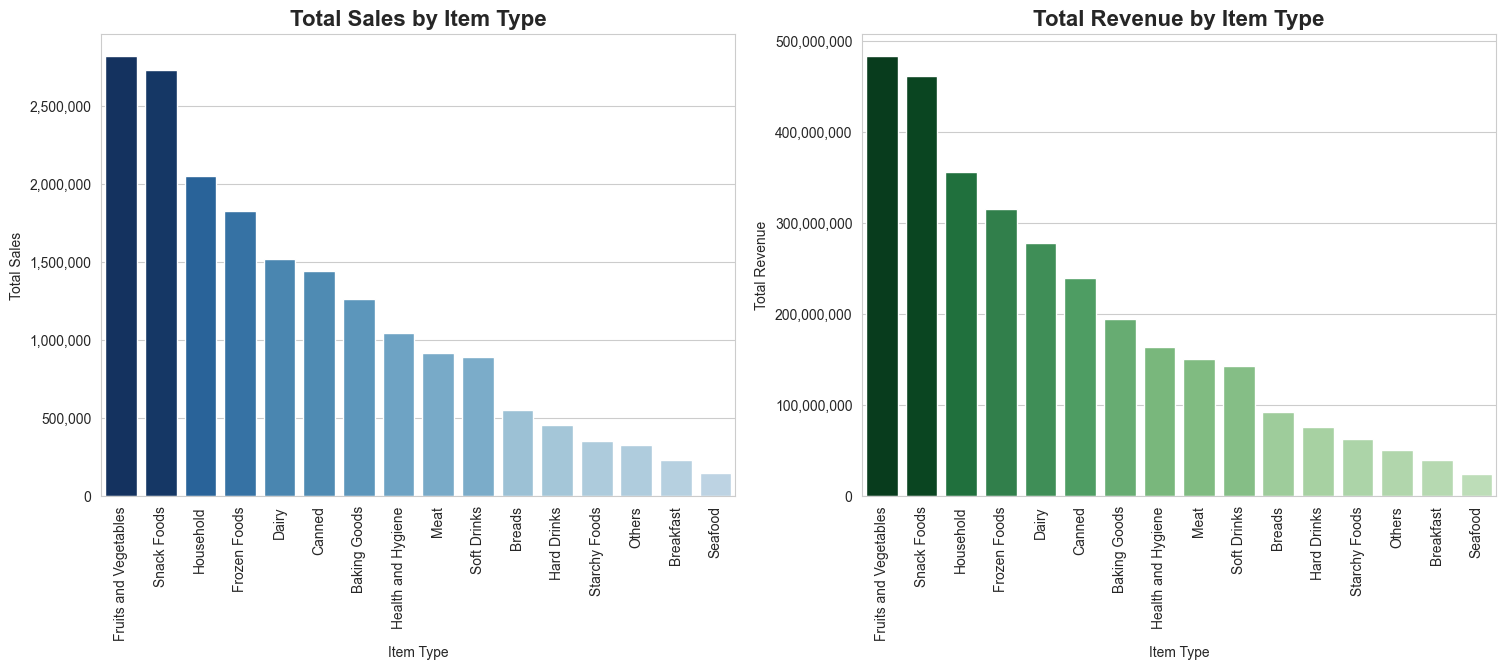

In [ ]:
# Matplotlib and Seaborn visualisation of the item type with the most sales and greatest revenue
# Let's create a bar plot showing the total sales and total revenue for each item type, highlighting the top-selling and highest-revenue item types.

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

cmap_blue = plt.cm.Blues
cmap_green = plt.cm.Greens

# Compute bar colors scaled to value — higher value maps to darker shade
def value_color(series, color):
    norm = (series - series.min()) / (series.max() - series.min())
    return [color(0.3 + 0.7 * v) for v in norm]


# Total Sales by Item Type
sns.barplot(x=item_type_sales.index, y=item_type_sales.values,
            hue=item_type_sales.index, palette=value_color(item_type_sales, cmap_blue), ax=axes[0])
axes[0].set_title("Total Sales by Item Type", fontweight='bold', fontsize=16)
axes[0].tick_params(axis='x', rotation=90)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].set_xlabel("Item Type")
axes[0].set_ylabel("Total Sales")

# Total Revenue by Item Type
sns.barplot(x=item_type_revenue.index, y=item_type_revenue.values,
            hue=item_type_revenue.index, palette=value_color(item_type_revenue, cmap_green), ax=axes[1])
axes[1].set_title("Total Revenue by Item Type", fontweight='bold', fontsize=16)
axes[1].tick_params(axis='x', rotation=90)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].set_xlabel("Item Type")
axes[1].set_ylabel("Total Revenue")

plt.show()

## 4. Feature: Identify trends in outlet size, age, location, and type on sales performance

### In this section we will identify correlations and trends in outlet demographics that may link to sales performance

## 5. Machine Learning: Regression modeling to predict future sales performance

### In this section we will implement basic machine learning and statistical techniques to predict future sales performance.